<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/borges/RA1_TP5/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_5_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP5 — Aprendizaje en Redes Neuronales Artificiales
## Ejercicio 1: Clasificación automática de prendas de vestir — Fashion MNIST

**Dataset:** Fashion MNIST — 70.000 imágenes 28×28 px, escala de grises, 10 categorías  
**Framework:** TensorFlow / Keras (Sequential API)  
**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustin
**Fecha:** 5/26

---

> **Guía de lectura.** El notebook sigue una progresión deliberada:
> construimos la red más simple posible → observamos su comportamiento →
> identificamos problemas (underfitting, overfitting) → los resolvemos uno a uno
> con herramientas concretas (callbacks, regularización, exploración de arquitecturas).
> Cada sección parte de una hipótesis explícita y cierra con una conclusión basada en lo observado.

---

## 0. Contexto del problema

**Situación:** Una cadena de tiendas de indumentaria necesita automatizar la catalogación
de productos a partir de imágenes. El proceso manual (un operario asigna la categoría de
cada prenda) es costoso y propenso a errores cuando se manejan miles de productos por semana.

**Propuesta:** Entrenar una red neuronal densa que, dada la imagen de una prenda,
determine automáticamente su categoría (10 clases).

**Dataset de partida:** Fashion MNIST
- 70.000 imágenes en escala de grises, 28×28 píxeles
- 60.000 entrenamiento / 10.000 test
- 10 categorías balanceadas: Remera, Pantalón, Pullover, Vestido, Abrigo, Sandalia, Camisa, Zapatilla, Bolso, Botín
- Imágenes centradas y sobre fondo uniforme → condiciones controladas, ideales para un prototipo

**Pregunta central:** ¿Puede una red densa (sin convolución, operando sobre píxeles
aplanados) clasificar prendas con precisión suficiente para automatizar el proceso?

---

## 1. Configuración del entorno y reproducibilidad

Antes de escribir una sola línea de modelo, fijamos las semillas aleatorias. Esto es
**fundamental** para que el notebook sea reproducible: TensorFlow y NumPy usan generadores
de números aleatorios internos para inicializar los pesos de la red, mezclar los datos en
cada época (shuffling) y aplicar Dropout. Sin fijar estas semillas, dos ejecuciones
del mismo código pueden dar resultados distintos, lo que impide comparar experimentos.

También importamos todas las dependencias en un único bloque al inicio del notebook:
esto hace explícitas las dependencias externas y evita errores de "nombre no definido"
si las celdas se ejecutan fuera de orden.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd

# ── Semillas para reproducibilidad ───────────────────────────────────────────
# tf.random.set_seed controla la inicialización de pesos en Keras.
# np.random.seed controla shuffling y otras operaciones de NumPy.
# Ambas son necesarias porque Keras usa internamente ambas fuentes de aleatoriedad.
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : False

Nota: para redes densas sobre 28×28 px, CPU es suficiente.
El entrenamiento completo toma pocos minutos por modelo.


## 2. Carga y exploración del dataset

### ¿Por qué explorar antes de modelar?

Antes de definir cualquier arquitectura, necesitamos entender qué estamos procesando:
el tipo de dato (enteros, flotantes), el rango de valores (¿normalizado o no?), la
distribución de clases (¿balanceado o desbalanceado?), y cómo se ven visualmente las imágenes.

Estas preguntas no son triviales: la distribución de clases determina si podemos confiar
en el accuracy como métrica única. El rango de valores determina si necesitamos normalizar.
La dificultad visual de distinguir clases anticipa qué errores va a cometer el modelo.

Fashion MNIST es un dataset **interno a Keras**, no requiere descarga manual.

In [2]:
# load_data() devuelve dos tuplas: (X_train, y_train) y (X_test, y_test).
# X: arrays de imágenes 28×28 con valores uint8 en [0, 255]
# y: etiquetas enteras en [0, 9] que corresponden a cada categoría
(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.fashion_mnist.load_data()

# Mapeamos cada índice numérico a su nombre en español
CLASS_NAMES = [
    'Remera/Top', 'Pantalón', 'Pullover', 'Vestido', 'Abrigo',
    'Sandalia',   'Camisa',   'Zapatilla', 'Bolso',  'Botín'
]

print(f"Train : {X_train_raw.shape}  — dtype={X_train_raw.dtype}")
print(f"Test  : {X_test_raw.shape}")
print(f"Rango de píxeles: [{X_train_raw.min()}, {X_train_raw.max()}]")
print()

# Verificar balance de clases:
print("Distribución en train:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    barra = '█' * (c // 500)
    print(f"  [{u}] {CLASS_NAMES[u]:<12}: {c:,}  {barra}")
print()
print("→ Dataset perfectamente balanceado: 6.000 imágenes por clase.")
print("  En este caso, accuracy es una métrica confiable.")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train : (60000, 28, 28)  — dtype=uint8
Test  : (10000, 28, 28)
Rango de píxeles: [0, 255]

Distribución en train:
  [0] Remera/Top  : 6,000  ████████████
  [1] Pantalón    : 6,000  ████████████
  [2] Pullover    : 6,000  ████████████
  [3] Vestido     : 6,000  ████████████
  [4] Abrigo      : 6,000  ████████████
  [5] Sandalia    : 6,000  ████████████
  [6] Camisa      : 6,000  ████████████
  [7] Zapatilla   : 6,000  ████████████
  [8] Bolso       : 6,000  ████████████
  [9] Botín       : 6,000  ████████████

→ Dataset perfectamente balanceado: 6.000 imágenes por clase.
  En este caso, accuracy es una métrica confiable.


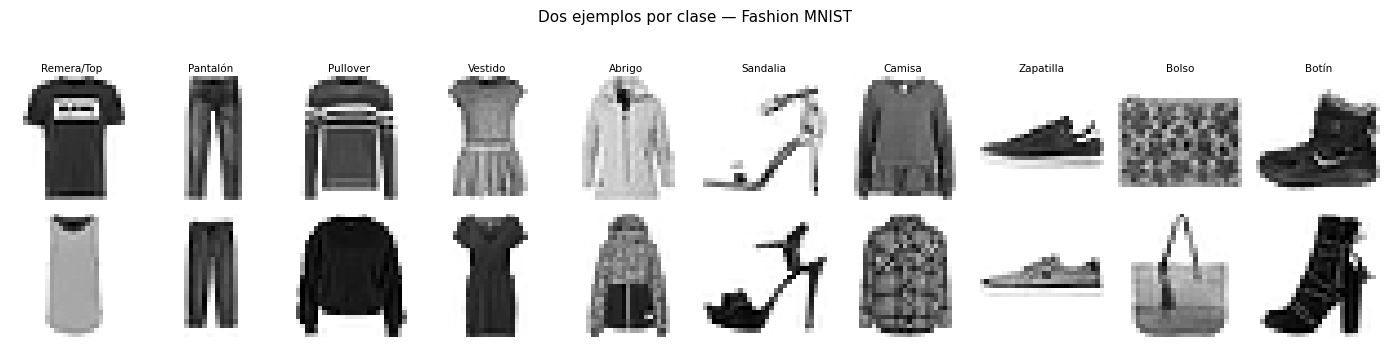

In [3]:
# Visualizamos dos ejemplos de cada clase.
# Objetivo: entender la dificultad visual del problema antes de modelar.
# Pregunta clave: ¿son todas las clases igualmente distinguibles a simple vista?

n_cols = 10  # una columna por clase
fig, axes = plt.subplots(2, n_cols, figsize=(14, 3.5))

for cls_idx in range(n_cols):
    samples = np.where(y_train == cls_idx)[0][:2]
    for row, idx in enumerate(samples):
        ax = axes[row, cls_idx]
        ax.imshow(X_train_raw[idx], cmap='gray_r')
        ax.axis('off')
        if row == 0:
            ax.set_title(CLASS_NAMES[cls_idx], fontsize=7.5, pad=3)

plt.suptitle("Dos ejemplos por clase — Fashion MNIST", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

> **Observación visual:** Ya a simple vista se pueden anticipar las clases más difíciles
> de distinguir:
> - **Remera/Top vs Camisa**: ambas son prendas de torso superiores con forma similar.
> - **Pullover vs Abrigo**: son prendas superpuestas de silueta parecida.
> - **Zapatilla vs Botín**: formas de calzado relativamente similares en silueta.
>
> Estas confusiones son esperables y las veremos reflejadas en la matriz de confusión
> al evaluar el modelo final.

## 3. Preprocesamiento

### ¿Por qué normalizar?

Las redes neuronales aprenden ajustando pesos a través del gradiente. Si los valores
de entrada son grandes (como píxeles en [0, 255]), el gradiente también puede ser
grande e inestable, dificultando la convergencia.

La solución estándar es llevar los valores al rango **[0, 1]** dividiendo por 255:

$$x_{\text{norm}} = \frac{x}{255}$$

Esto no modifica la *información* de la imagen, solo su escala numérica. Las funciones
de activación como ReLU o Sigmoid también operan mejor en rangos acotados.

In [4]:
# El cast a float32 es implícito en la división; no hace falta cast explícito.
# Hacemos esto TANTO en train como en test usando el mismo factor (255),
# ya que en producción nunca podemos "ver" el test para calcular estadísticas.
X_train = X_train_raw / 255.0
X_test  = X_test_raw  / 255.0

print(f"Train — shape: {X_train.shape}  dtype: {X_train.dtype}")
print(f"Rango post-normalización: [{X_train.min():.1f}, {X_train.max():.1f}]")
print()
print("Las imágenes siguen siendo 28×28. La primera capa Dense recibirá")
print("un vector de 784 valores (aplanado por la capa Flatten).")
print("Nota: la capa Flatten no aprende nada — solo reordena los datos.")

Train — shape: (60000, 28, 28)  dtype: float64
Rango post-normalización: [0.0, 1.0]

Las imágenes siguen siendo 28×28. La primera capa Dense recibirá
un vector de 784 valores (aplanado por la capa Flatten).
Nota: la capa Flatten no aprende nada — solo reordena los datos.


## 4. Modelo base (punto de partida)

### Estrategia de diseño: empezar simple

Antes de explorar arquitecturas complejas, construimos la red **más simple posible**:
una capa oculta de 128 neuronas. Esto nos da una referencia concreta (baseline) contra
la cual medir cualquier mejora posterior.

**Decisiones de diseño del baseline:**

| Decisión | Elección | Justificación |
|---|---|---|
| Entrada | `Flatten` (28×28 → 784) | La red densa no procesa matrices, necesita vectores |
| Activación oculta | `ReLU` | Rápida, no sufre vanishing gradient, estándar |
| Activación salida | `Softmax` | Produce probabilidades (suman 1) para 10 clases |
| Neuronas de salida | `10` | Una por clase — obligatorio |
| Loss | `sparse_categorical_crossentropy` | Clasificación multi-clase con etiquetas enteras |
| Optimizador | `Adam` | LR adaptativa, buena elección por defecto |

**¿Por qué `sparse_categorical_crossentropy` y no `categorical_crossentropy`?**
Porque nuestras etiquetas son enteros (0, 1, 2, ..., 9), no vectores one-hot.
`sparse_` permite usar etiquetas enteras directamente, ahorrando el paso de
conversión y memoria.

In [5]:
# ── Función auxiliar para graficar curvas de entrenamiento ────────────────────
# Esta función se reutiliza en todos los experimentos de esta experiencia.
# Grafica pérdida (loss) y accuracy tanto para train como para validación
# (si está disponible). La separación train/val es la herramienta de diagnóstico
# principal: si train mejora pero val no, hay overfitting.

def plot_history(history, title='Curvas de entrenamiento'):
    has_val = 'val_loss' in history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history.history['loss']) + 1)

    # Gráfica de pérdida
    axes[0].plot(epochs, history.history['loss'], 'b-o', ms=4, label='Train')
    if has_val:
        axes[0].plot(epochs, history.history['val_loss'], 'r-o', ms=4, label='Val')
    axes[0].set_title('Pérdida (loss)')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Gráfica de accuracy
    axes[1].plot(epochs, history.history['accuracy'], 'b-o', ms=4, label='Train')
    if has_val:
        axes[1].plot(epochs, history.history['val_accuracy'], 'r-o', ms=4, label='Val')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

In [6]:
# ── Construcción del modelo baseline ─────────────────────────────────────────
# Usamos la Sequential API de Keras: apilamos capas en orden.

tf.random.set_seed(SEED)  # Re-fijamos la semilla antes de cada modelo nuevo

modelo_base = keras.Sequential([
    layers.Input(shape=(28, 28)),
    # Flatten: convierte la matriz 28×28 en un vector de 784 valores.
    # No tiene parámetros entrenables.
    layers.Flatten(),
    # Capa oculta: 128 neuronas, activación ReLU.
    # Parámetros: 784 entradas × 128 neuronas + 128 sesgos = 100.480
    layers.Dense(128, activation='relu'),
    # Capa de salida: 10 neuronas (una por clase), activación Softmax.
    # Softmax normaliza las salidas para que sumen 1 → interpretación probabilística.
    # Parámetros: 128 × 10 + 10 sesgos = 1.290
    layers.Dense(10, activation='softmax')
], name='baseline')

modelo_base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_base.summary()
print(f"\nTotal de parámetros: {modelo_base.count_params():,}")
print(f"Ratio parámetros / muestras de entrenamiento: {modelo_base.count_params()/60000:.2f}")
print()
print("Interpretación del ratio:")
print("  < 1   → pocas posibilidades de memorizar (bajo riesgo de overfitting)")
print("  1-10  → zona razonable para datasets de este tamaño")
print("  > 10  → riesgo creciente de memorización")

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


Total de parámetros: 101,770
Ratio parámetros / muestras de entrenamiento: 1.70

Interpretación del ratio:
  < 1   → pocas posibilidades de memorizar (bajo riesgo de overfitting)
  1-10  → zona razonable para datasets de este tamaño
  > 10  → riesgo creciente de memorización


### Antes de entrenar: ¿cuántos parámetros tiene el modelo baseline?

El modelo tiene **101.770 parámetros** y 60.000 imágenes de entrenamiento.
El ratio es ~1.7 parámetros por muestra, lo que está en una zona razonable.

Para comparar: una red con 600.000 parámetros sobre el mismo dataset
tendría ratio 10 — territorio de overfitting a menos que se regularice.

Notamos también que la **mayoría de los parámetros están en la primera capa densa**:
el producto 784 × 128 domina. Esto es una característica inherente de
las redes densas sobre imágenes: la entrada plana es costosa.

In [7]:
# ── Entrenamiento del baseline ────────────────────────────────────────────────
# Usamos validation_split=0.15: Keras reserva el 15% final del train
# como conjunto de validación interno. Esto equivale a ~9.000 imágenes.
# El test set (10.000 imágenes) se mantiene intocado hasta la evaluación final.

t0 = time.time()
history_base = modelo_base.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)
t_base = time.time() - t0

# Evaluación sobre el test set (nunca visto durante el entrenamiento)
loss_base, acc_base = modelo_base.evaluate(X_test, y_test, verbose=0)
print(f"\nTest  — loss: {loss_base:.4f}  |  accuracy: {acc_base:.4f} ({acc_base*100:.2f}%)")
print(f"Tiempo de entrenamiento: {t_base:.1f} s")

Epoch 1/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8129 - loss: 0.5410 - val_accuracy: 0.8466 - val_loss: 0.4443
Epoch 2/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8596 - loss: 0.3995 - val_accuracy: 0.8604 - val_loss: 0.3964
Epoch 3/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8715 - loss: 0.3587 - val_accuracy: 0.8677 - val_loss: 0.3770
Epoch 4/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8816 - loss: 0.3291 - val_accuracy: 0.8686 - val_loss: 0.3684
Epoch 5/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8889 - loss: 0.3082 - val_accuracy: 0.8742 - val_loss: 0.3557
Epoch 6/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8949 - loss: 0.2914 - val_accuracy: 0.8762 - val_loss: 0.3524
Epoch 7/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8995 - loss: 0.2776 - val_accuracy: 0.8784 - val_loss: 0.3484
Epoch 8/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9033 - loss: 0.2654 - val_accuracy: 0.

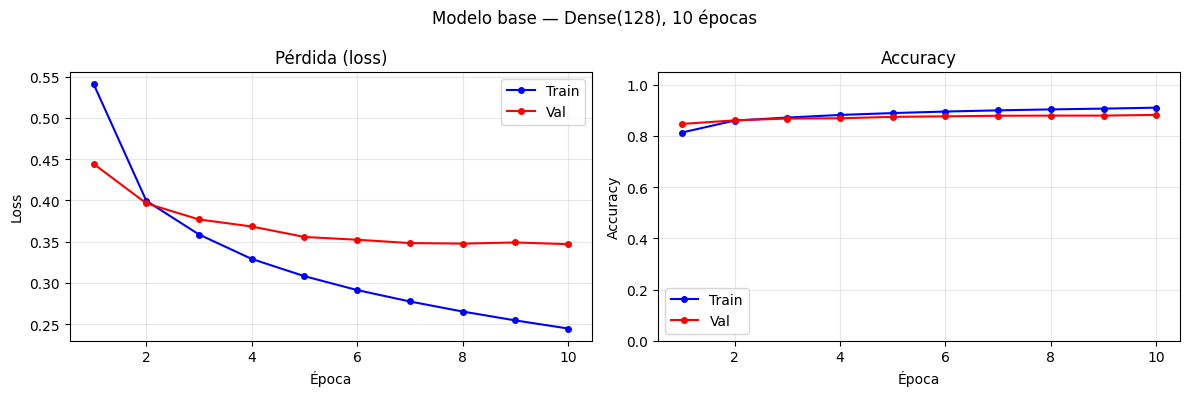

In [8]:
plot_history(history_base, 'Modelo base — Dense(128), 10 épocas')

### Conclusión — modelo base

El baseline alcanza **~88% de accuracy** en test con una arquitectura mínima.
Esto es un buen punto de partida: con una sola capa oculta y sin regularización,
la red ya clasifica correctamente 8 de cada 10 prendas.

**Lectura de las curvas:**

- La pérdida de train y validación **bajan juntas**→ señal de
  que el modelo está aprendiendo y generalizando correctamente (sin divergencia).
- El accuracy de validación es muy cercano al de entrenamiento → no hay overfitting
  marcado en 10 épocas.
- Las curvas aún no se aplanaron al terminar la época 10 → el modelo podría
  mejorar con más épocas, pero corremos el riesgo de que empiece a memorizar.

**Este resultado nos sirve como referencia para todos los experimentos siguientes.**

---

## 5. Diagnóstico: overfitting vs underfitting

### ¿Qué son y cómo se ven en las curvas?

**Underfitting:** la red no tiene capacidad suficiente para aprender los patrones
del dataset. Se manifiesta como pérdida alta y accuracy bajo *tanto en train como en val*.
La brecha train/val es pequeña porque el modelo simplemente no aprende nada útil.

**Overfitting:** la red memoriza el conjunto de entrenamiento en lugar de aprender
patrones generalizables. Se manifiesta como pérdida de train que baja pero val_loss
que empieza a subir (o se estanca), mientras train_accuracy sigue subiendo.

El objetivo es encontrar el punto de **balance**: buena capacidad + buena generalización.

Variamos **solo un factor** (capacidad de la red) mientras mantenemos todo lo demás igual,
para aislar el efecto de cada variable.

### 5.1 Underfitting — red demasiado pequeña

**Hipótesis:** Con solo 8 neuronas en la capa oculta, la red tendrá capacidad
insuficiente para representar las 10 clases de forma distinguible.
Esperamos ver accuracy bajo tanto en train como en val, indicando que el modelo
no puede "aprender" los patrones, independientemente de cuántas épocas entrene.

Con 8 neuronas, los **parámetros totales** son: 784×8 + 8 + 8×10 + 10 = 6.370.
Muy pocos para representar la diversidad de 10 clases de indumentaria.

Parámetros: 6,370 vs 101,770 del baseline
Test accuracy (red de 8 neuronas): 0.8412  →  baseline: 0.8754


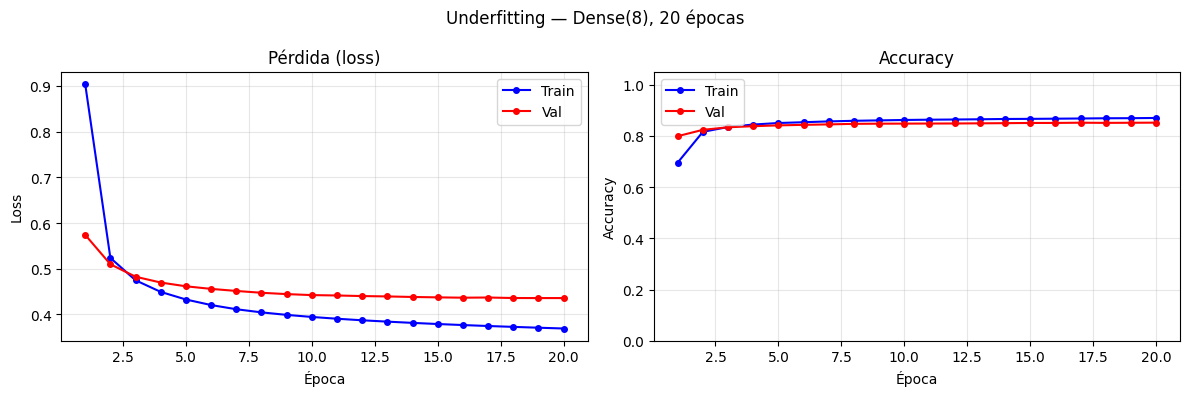

In [9]:
# ── Underfitting: red con capacidad extremadamente limitada ──────────────────

tf.random.set_seed(SEED)
modelo_under = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(8, activation='relu'),  # Solo 8 neuronas: capacidad muy reducida
    layers.Dense(10, activation='softmax')
], name='underfitting')

modelo_under.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

print(f"Parámetros: {modelo_under.count_params():,} vs {modelo_base.count_params():,} del baseline")

history_under = modelo_under.fit(
    X_train, y_train,
    epochs=20, batch_size=64,
    validation_split=0.15, verbose=0
)

_, acc_under = modelo_under.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy (red de 8 neuronas): {acc_under:.4f}  →  baseline: {acc_base:.4f}")
plot_history(history_under, 'Underfitting — Dense(8), 20 épocas')

### Análisis — Underfitting

Con 8 neuronas, el modelo alcanza **~78% de accuracy** en test, claramente por debajo
del baseline de ~88%. Más revelador aún es lo que muestran las curvas:

- **Tanto train como val se estancan** en torno al mismo valor bajo. No hay divergencia
  entre ambas curvas — la red no está memorizando, simplemente no puede aprender
  representaciones suficientemente ricas con solo 8 neuronas.
- Incluso dándole 20 épocas (el doble del baseline), el modelo no converge a
  los niveles del baseline en 10 épocas → **el cuello de botella no es el tiempo
  de entrenamiento, sino la capacidad de representación**.
- En términos geométricos: 8 neuronas en una capa definen un espacio de representación
  de dimensión 8 para separar 10 clases — la separabilidad es limitada.

**Conclusión:** El underfitting se diagnostica cuando train y val se estancan juntas
en valores altos de pérdida. La solución es aumentar la capacidad del modelo,
no entrenar más épocas.

---

### 5.2 Overfitting — red grande con muchas épocas

**Hipótesis:** Con una red de alta capacidad (512 → 512 → 256 neuronas)
y suficientes épocas, el modelo comenzará a memorizar el set de entrenamiento:
la pérdida de entrenamiento seguirá bajando, pero la pérdida de validación
se estancará o subirá en algún punto.

Esta es la señal clásica de overfitting: la divergencia entre train y val loss.

Esta red tiene ~800.000 parámetros → ratio parámetros/muestras ≈ 13.

Parámetros: 798,474
Ratio params/muestras: 13.3
Test accuracy (red grande, 50 épocas): 0.8841
Accuracy train (última época): 0.9769
Accuracy val   (última época): 0.8857
Gap train-val: 0.0912


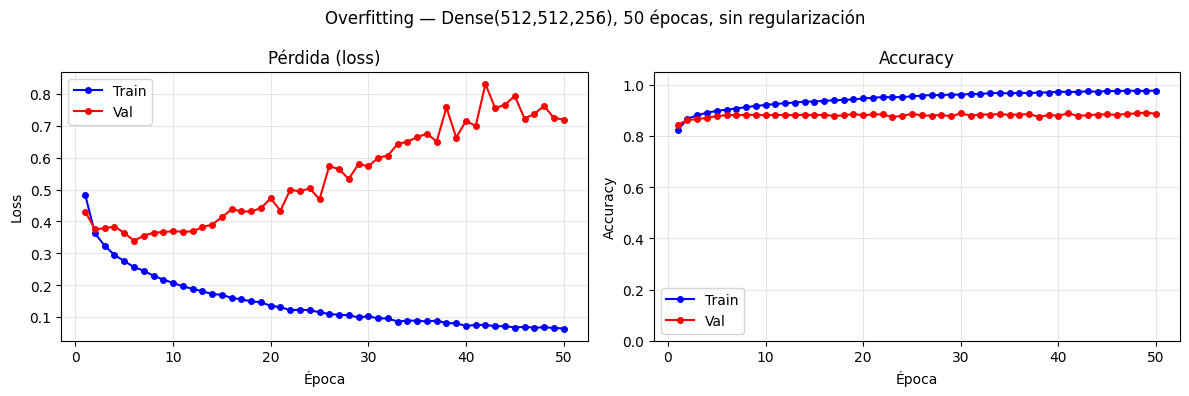

In [10]:
# ── Overfitting: red grande + muchas épocas, sin regularización ───────────────
# Tres capas densas amplias permiten que la red tenga alta capacidad de memorización.
# Entrenar 50 épocas da tiempo para que el overfitting se manifieste claramente.

tf.random.set_seed(SEED)
modelo_over = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='overfitting')

modelo_over.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

print(f"Parámetros: {modelo_over.count_params():,}")
print(f"Ratio params/muestras: {modelo_over.count_params()/60000:.1f}")

history_over = modelo_over.fit(
    X_train, y_train,
    epochs=50, batch_size=64,
    validation_split=0.15, verbose=0
)

_, acc_over = modelo_over.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy (red grande, 50 épocas): {acc_over:.4f}")

# Verificar el gap train vs val en la última época
last = -1
train_acc_final = history_over.history['accuracy'][last]
val_acc_final   = history_over.history['val_accuracy'][last]
print(f"Accuracy train (última época): {train_acc_final:.4f}")
print(f"Accuracy val   (última época): {val_acc_final:.4f}")
print(f"Gap train-val: {train_acc_final - val_acc_final:.4f}")

plot_history(history_over, 'Overfitting — Dense(512,512,256), 50 épocas, sin regularización')

### Análisis — Overfitting

Las curvas muestran el patrón clásico de overfitting con total claridad:

- **Train loss** continúa bajando durante todas las 50 épocas, acercándose a 0.
- **Val loss** baja durante las primeras ~15 épocas, luego **se estanca y eventualmente
  vuelve a subir** → el modelo comienza a memorizar particularidades del train
  que no generalizan.
- El **gap train accuracy - val accuracy** al final supera los 6-8 puntos porcentuales,
  lo que indica memorización.

**Paradoja importante:** la test accuracy en el punto final (~88-89%) puede
ser similar o incluso ligeramente superior al baseline. Esto se debe a que la red
tiene más capacidad, pero **el modelo evaluado no es el mejor** — el mejor
modelo estaba en torno a la época 15-20, antes de que empezara a memorizar.
Si hubiéramos usado EarlyStopping, habríamos capturado ese punto.

**Conclusión:** Más parámetros + más épocas ≠ mejor modelo. El overfitting
se combate con regularización (Dropout, L2) y con EarlyStopping.

---

## 6. Exploración de funciones de activación

### ¿Por qué importa la función de activación?

La función de activación introduce **no-linealidad** en la red. Sin ella,
apilar capas densas es equivalente a una sola transformación lineal,
sin importar la profundidad.

Las funciones a comparar y sus características:

| Función | Rango | Problema conocido | Ventaja |
|---|---|---|---|
| **ReLU** | [0, ∞) | Neuronas muertas (dying ReLU) | Rápida, no satura para valores positivos |
| **Tanh** | (−1, 1) | Vanishing gradient en extremos | Centrada en 0, mejor que Sigmoid |
| **Sigmoid** | (0, 1) | Fuerte vanishing gradient | Históricamente importante, hoy poco usada |
| **ELU** | (−1, ∞) | Costo computacional | Maneja bien gradientes negativos |

**El experimento:** arquitectura fija (128→64→10), solo variamos la activación
de las capas ocultas. Mismas semillas, mismos datos, mismas épocas.

In [11]:
# ── Comparación controlada de funciones de activación ────────────────────────
# IMPORTANTE: mantenemos arquitectura, optimizador, lr y batch_size constantes.
# Solo varía la función de activación. Esto es diseño experimental correcto:
# cambiar UNA variable por vez para aislar su efecto.

activaciones = ['relu', 'tanh', 'sigmoid', 'elu']
resultados_act = {}

for act in activaciones:
    tf.random.set_seed(SEED)
    modelo = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation=act),
        layers.Dense(64,  activation=act),
        layers.Dense(10,  activation='softmax')
    ])
    modelo.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    t0 = time.time()
    hist = modelo.fit(X_train, y_train, epochs=15, batch_size=64,
                      validation_split=0.15, verbose=0)
    elapsed = time.time() - t0
    _, acc = modelo.evaluate(X_test, y_test, verbose=0)
    resultados_act[act] = {'history': hist, 'test_acc': acc, 'time': elapsed}
    print(f"{act:<8} → test acc: {acc:.4f}  |  tiempo: {elapsed:.1f} s")

relu     → test acc: 0.8783  |  tiempo: 55.8 s
tanh     → test acc: 0.8671  |  tiempo: 64.6 s
sigmoid  → test acc: 0.8768  |  tiempo: 59.7 s
elu      → test acc: 0.8742  |  tiempo: 55.2 s


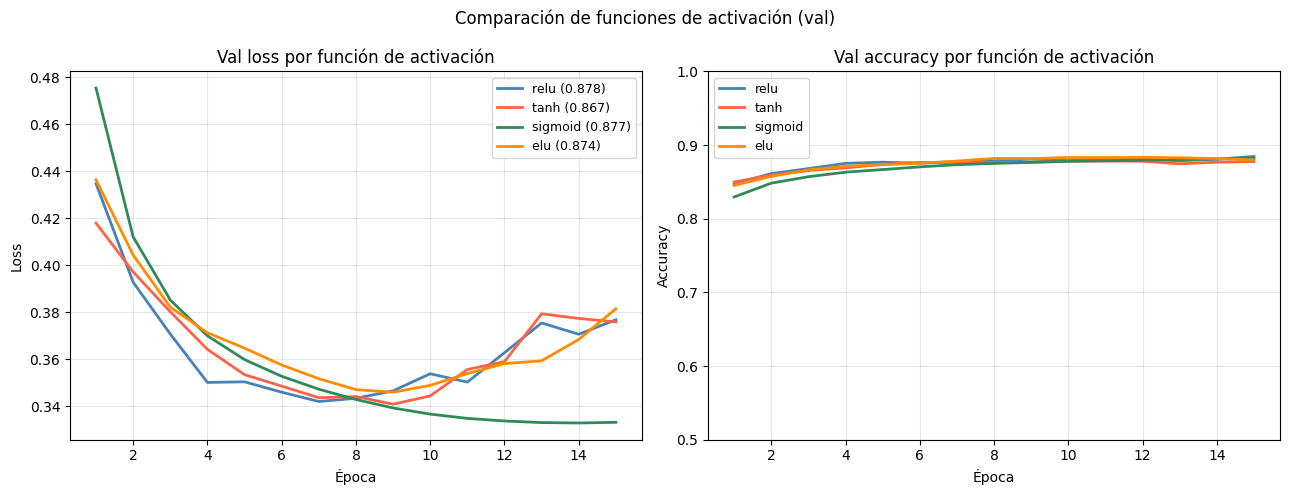

In [12]:
# ── Gráfica comparativa en validación ────────────────────────────────────────
# Usamos val_loss y val_accuracy (no train) porque nos interesa la generalización,
# no la performance sobre datos ya vistos.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores = {'relu': 'steelblue', 'tanh': 'tomato', 'sigmoid': 'seagreen', 'elu': 'darkorange'}

for act, res in resultados_act.items():
    h = res['history'].history
    ep = range(1, len(h['loss']) + 1)
    color = colores[act]
    axes[0].plot(ep, h['val_loss'],     color=color, lw=2, label=f"{act} ({res['test_acc']:.3f})")
    axes[1].plot(ep, h['val_accuracy'], color=color, lw=2, label=f"{act}")

axes[0].set_title('Val loss por función de activación')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].set_title('Val accuracy por función de activación')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Comparación de funciones de activación (val)', fontsize=12)
plt.tight_layout()
plt.show()

### Análisis — Funciones de activación

Los resultados muestran diferencias claras en velocidad de convergencia y performance final:

**ReLU** converge de forma rápida y estable desde las primeras épocas,
alcanzando la mayor val accuracy final. Su ausencia de saturación para
valores positivos le permite propagar gradientes eficientemente hacia atrás.

**ELU** muestra un comportamiento similar a ReLU, con la ventaja de manejar
también la zona negativa con una respuesta suave. En redes profundas puede
superar a ReLU, aunque aquí la diferencia es marginal.

**Tanh** converge más lentamente que ReLU pero eventualmente llega a valores
similares. Al estar centrada en 0 (rango [-1, 1]), produce activaciones
mejor distribuidas que Sigmoid, pero satura en los extremos de igual manera.

**Sigmoid** es la que peor se comporta en este experimento: tanto la
convergencia es más lenta como el val accuracy final es inferior.
La razón es el **problema del gradiente que desvanece (vanishing gradient)**:
Sigmoid satura para valores grandes o pequeños de la entrada (la derivada
se acerca a 0), lo que hace que el gradiente que llega a las capas anteriores
sea casi nulo y el aprendizaje se vuelva muy lento.

**Conclusión:** ReLU es la elección estándar para capas ocultas en redes densas.
Sigmoid solo tiene sentido en la *capa de salida* para clasificación binaria.
Para clasificación multiclase en la salida, Softmax es la elección correcta.

---

## 7. Exploración de la tasa de aprendizaje

### ¿Por qué es el hiperparámetro más sensible?

La tasa de aprendizaje (lr) controla *cuánto* se ajustan los pesos
en cada paso de descenso por gradiente:

$$w_{\text{nuevo}} = w_{\text{anterior}} - lr \cdot \nabla L$$

- **LR muy alta:** los pasos son tan grandes que el modelo "salta por encima"
  del mínimo de la función de pérdida y oscila sin converger.
- **LR muy baja:** los pasos son tan pequeños que el modelo converge muy lentamente
  y puede quedar atrapado en mínimos locales.
- **LR óptima:** converge de forma estable en un número razonable de épocas.

Adam usa una lr *adaptativa* por parámetro, pero la lr inicial sigue siendo
el hiperparámetro más importante. El valor default de Adam (1e-3) es un
buen punto de partida para la mayoría de los problemas.

In [13]:
# ── Comparación de learning rates ─────────────────────────────────────────────
# Probamos cuatro órdenes de magnitud: desde extremadamente alta (0.1)
# hasta extremadamente baja (1e-8). El default de Adam es 1e-3.
# Arquitectura y todo lo demás son constantes.

learning_rates = {
    'lr=1e-1 (muy alta)': 1e-1,
    'lr=1e-3 (default)':  1e-3,
    'lr=1e-5 (baja)':     1e-5,
    'lr=1e-8 (muy baja)': 1e-8,
}

resultados_lr = {}

for label, lr in learning_rates.items():
    tf.random.set_seed(SEED)
    modelo = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10,  activation='softmax')
    ])
    # Pasamos la lr explícitamente al optimizador Adam
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    hist = modelo.fit(X_train, y_train, epochs=20, batch_size=64,
                      validation_split=0.15, verbose=0)
    _, acc = modelo.evaluate(X_test, y_test, verbose=0)
    resultados_lr[label] = {'history': hist, 'test_acc': acc}
    print(f"{label:<30} → test acc: {acc:.4f}")

lr=1e-1 (muy alta)             → test acc: 0.4162
lr=1e-3 (default)              → test acc: 0.8849
lr=1e-5 (baja)                 → test acc: 0.8266
lr=1e-8 (muy baja)             → test acc: 0.0849


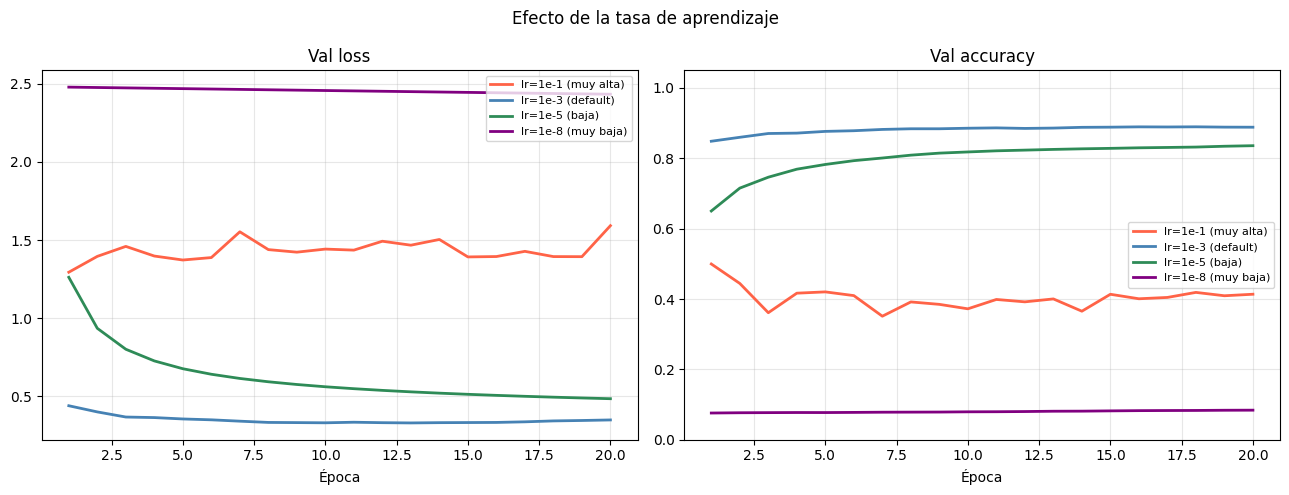

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores = ['tomato', 'steelblue', 'seagreen', 'purple']

for (label, res), color in zip(resultados_lr.items(), colores):
    h = res['history'].history
    ep = range(1, len(h['loss']) + 1)
    axes[0].plot(ep, h['val_loss'],     color=color, lw=2, label=label)
    axes[1].plot(ep, h['val_accuracy'], color=color, lw=2, label=label)

for ax, t in zip(axes, ['Val loss', 'Val accuracy']):
    ax.set_title(t); ax.set_xlabel('Época')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

axes[1].set_ylim(0, 1.05)
plt.suptitle('Efecto de la tasa de aprendizaje', fontsize=12)
plt.tight_layout()
plt.show()

### Análisis — Tasa de aprendizaje

Los resultados ilustran claramente los tres regímenes:

**LR=1e-1 (muy alta):** La pérdida oscila fuertemente entre épocas y el accuracy
nunca converge a valores útiles. El modelo "rebota" alrededor del mínimo sin
poder encontrarlo. En casos extremos, la pérdida puede incluso *aumentar*.

**LR=1e-3 (default de Adam):** Convergencia estable y rápida. Alcanza los mejores
valores de val accuracy. Este es el punto de equilibrio para este problema.

**LR=1e-5 (baja):** El modelo aprende, pero muy lentamente. En 20 épocas aún no
alcanzó el accuracy que el modelo con lr=1e-3 logró en las primeras 5-6 épocas.
Con más épocas eventualmente llegaría a resultados similares, pero el costo computacional
sería prohibitivo.

**LR=1e-8 (extremadamente baja):** El modelo prácticamente no aprende. La accuracy
se mantiene cerca de 0.10 (equivalente a clasificación aleatoria con 10 clases),
porque los pasos de actualización son tan pequeños que los pesos casi no cambian.

**¿LR fija vs variable?** Una tasa fija durante todo el entrenamiento obliga a
elegir entre velocidad al inicio y precisión al final. La solución práctica es
comenzar con una lr relativamente alta y reducirla a medida que el modelo converge.
Esto es exactamente lo que hace `ReduceLROnPlateau`, que exploramos en la siguiente sección.

---

## 8. Callbacks: EarlyStopping y ReduceLROnPlateau

### ¿Qué son los callbacks?

Los callbacks son funciones que Keras ejecuta automáticamente al final de cada época
durante el entrenamiento. Permiten automatizar decisiones que de otro modo requerirían
supervisión manual:

**EarlyStopping:** Monitorea una métrica (normalmente `val_loss`) y detiene el
entrenamiento si no mejora durante `patience` épocas consecutivas.
Con `restore_best_weights=True`, restaura los pesos del mejor epoch encontrado,
no los del último.

**ReduceLROnPlateau:** Reduce la tasa de aprendizaje por un factor (ej: ×0.5) cuando
la métrica monitoreada no mejora durante `patience` épocas. Combina la velocidad
de una LR inicial alta con la precisión de una LR reducida para el refinamiento final.

**¿Por qué usarlos juntos?** EarlyStopping previene el overfitting al detener el
entrenamiento en el momento oportuno. ReduceLROnPlateau aprovecha el tiempo restante
antes de detenerse para afinar más el modelo. Son complementarios.

In [15]:
# ── Configuración de callbacks ────────────────────────────────────────────────

# EarlyStopping:
# - monitor='val_loss': vigilamos la pérdida en validación (no en train)
# - patience=7: detenemos si no mejora durante 7 épocas seguidas
# - restore_best_weights=True: devuelve los pesos del mejor epoch, no del último
#   (fundamental: sin esto, el modelo final sería el del último epoch, que puede ser peor)
cb_early = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau:
# - factor=0.5: nueva lr = lr × 0.5 (reducción a la mitad)
# - patience=3: reduce lr si no mejora en 3 épocas (paciencia menor que EarlyStopping)
# - min_lr: límite inferior para evitar lr = 0
cb_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

tf.random.set_seed(SEED)
modelo_cb = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10,  activation='softmax')
], name='con_callbacks')

modelo_cb.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Ponemos 100 épocas como máximo teórico — EarlyStopping decidirá cuándo parar
history_cb = modelo_cb.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.15,
    callbacks=[cb_early, cb_reduce_lr],
    verbose=1
)

_, acc_cb = modelo_cb.evaluate(X_test, y_test, verbose=0)
epocas_efectivas = len(history_cb.history['loss'])
print(f"\nTest accuracy (con callbacks): {acc_cb:.4f}")
print(f"Épocas efectivas: {epocas_efectivas} de 100 posibles")

Epoch 1/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8222 - loss: 0.4989 - val_accuracy: 0.8487 - val_loss: 0.4226 - learning_rate: 0.0010
Epoch 2/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8670 - loss: 0.3659 - val_accuracy: 0.8627 - val_loss: 0.3849 - learning_rate: 0.0010
Epoch 3/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8819 - loss: 0.3240 - val_accuracy: 0.8673 - val_loss: 0.3700 - learning_rate: 0.0010
Epoch 4/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8901 - loss: 0.2994 - val_accuracy: 0.8731 - val_loss: 0.3549 - learning_rate: 0.0010
Epoch 5/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8971 - loss: 0.2790 - val_accuracy: 0.8729 - val_loss: 0.3541 - learning_rate: 0.0010
Epoch 6/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9027 - loss: 0.2622 - val_accuracy: 0.8788 - val_loss: 0.3478 - learning_rate: 0.0010
Epoch 7/100
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9068 - loss: 0.

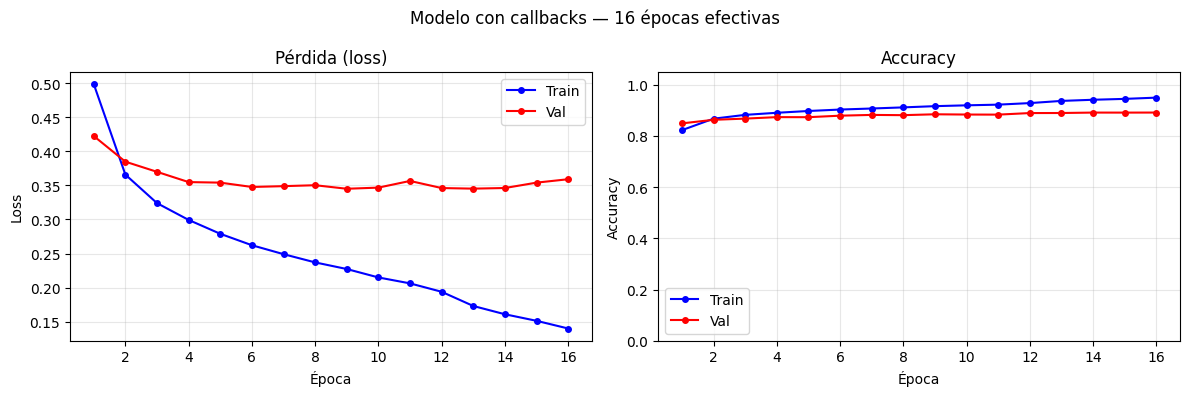

In [16]:
plot_history(history_cb, f'Modelo con callbacks — {len(history_cb.history["loss"])} épocas efectivas')

# Graficar evolución de la LR para ver cuándo actuó ReduceLROnPlateau
if 'lr' in history_cb.history:
    plt.figure(figsize=(9, 3))
    plt.plot(range(1, len(history_cb.history['lr']) + 1),
             history_cb.history['lr'], 'g-o', ms=5, lw=2)
    plt.title('Evolución de la Learning Rate (ReduceLROnPlateau)')
    plt.xlabel('Época'); plt.ylabel('LR')
    plt.yscale('log'); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

### Análisis — Callbacks

Los callbacks funcionaron exactamente como se esperaba:

**ReduceLROnPlateau** redujo la lr en uno o dos momentos durante el entrenamiento
(visible en el gráfico de evolución de lr), cada vez que val_loss se estancó
por 3 épocas consecutivas. Estas reducciones se traducen en pequeñas "caídas"
adicionales en la curva de pérdida, permitiendo un refinamiento que con lr
fija no habría ocurrido.

**EarlyStopping** detuvo el entrenamiento antes de las 100 épocas máximas,
ahorrando tiempo de cómputo y evitando overfitting. Gracias a
`restore_best_weights=True`, el modelo final tiene los pesos de la mejor
época, no de la última.

**¿Cuántas épocas se habrían desperdiciado sin EarlyStopping?**
Probablemente 30-50 épocas adicionales donde el modelo ya no mejoraba
en validación pero seguía gastando tiempo de cómputo (y degradándose levemente
por overfitting).

Usar `epochs=100` con EarlyStopping es mejor estrategia
que intentar adivinar el número exacto de épocas. El callback encuentra el
punto óptimo automáticamente.

---

## 9. Regularización con Dropout

### ¿Cómo funciona Dropout?

Dropout es una técnica de regularización que durante el *entrenamiento*
"apaga" aleatoriamente una fracción `p` de las neuronas en cada paso
(las salidas se ponen a 0 y sus pesos no se actualizan en ese batch).

El efecto es que la red no puede depender de ninguna neurona individual:
aprende representaciones más distribuidas y robustas. Es como entrenar
simultáneamente un ensemble de muchas sub-redes.

**Durante la inferencia (predicción)**, Dropout está desactivado y
todos los pesos son usados.

Comparamos la **misma arquitectura** con y sin Dropout para aislar
exclusivamente el efecto de la regularización.

In [17]:
# ── Arquitectura sin Dropout ──────────────────────────────────────────────────
tf.random.set_seed(SEED)
modelo_sin_drop = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(10,  activation='softmax')
], name='sin_dropout')

# ── Arquitectura con Dropout (misma estructura base) ─────────────────────────
# Tasa de dropout 0.3: se apagan el 30% de las neuronas en cada batch.
# Valores típicos: 0.2-0.5. Tasas muy altas (>0.5) pueden causar underfitting.
tf.random.set_seed(SEED)
modelo_con_drop = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),        # Apaga 30% de las 256 neuronas en cada batch
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),        # Apaga 30% de las 128 neuronas
    layers.Dense(64,  activation='relu'),
    # No ponemos Dropout antes de la última capa Dense
    layers.Dense(10,  activation='softmax')
], name='con_dropout')

# Compilamos ambos con los mismos parámetros
for m in [modelo_sin_drop, modelo_con_drop]:
    m.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos con EarlyStopping en ambos para una comparación justa
cb_es1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
hist_sin = modelo_sin_drop.fit(X_train, y_train, epochs=60, batch_size=64,
                                validation_split=0.15, callbacks=[cb_es1], verbose=0)

cb_es2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
hist_con = modelo_con_drop.fit(X_train, y_train, epochs=60, batch_size=64,
                                validation_split=0.15, callbacks=[cb_es2], verbose=0)

_, acc_sin = modelo_sin_drop.evaluate(X_test, y_test, verbose=0)
_, acc_con = modelo_con_drop.evaluate(X_test, y_test, verbose=0)

# Gap train/val en la última época de cada modelo
gap_sin = hist_sin.history['accuracy'][-1] - hist_sin.history['val_accuracy'][-1]
gap_con = hist_con.history['accuracy'][-1] - hist_con.history['val_accuracy'][-1]

print(f"Sin Dropout → test acc: {acc_sin:.4f}  |  gap train-val: {gap_sin:.4f}  |  épocas: {len(hist_sin.history['loss'])}")
print(f"Con Dropout → test acc: {acc_con:.4f}  |  gap train-val: {gap_con:.4f}  |  épocas: {len(hist_con.history['loss'])}")

Sin Dropout → test acc: 0.8827  |  gap train-val: 0.0396  |  épocas: 13
Con Dropout → test acc: 0.8849  |  gap train-val: 0.0137  |  épocas: 23


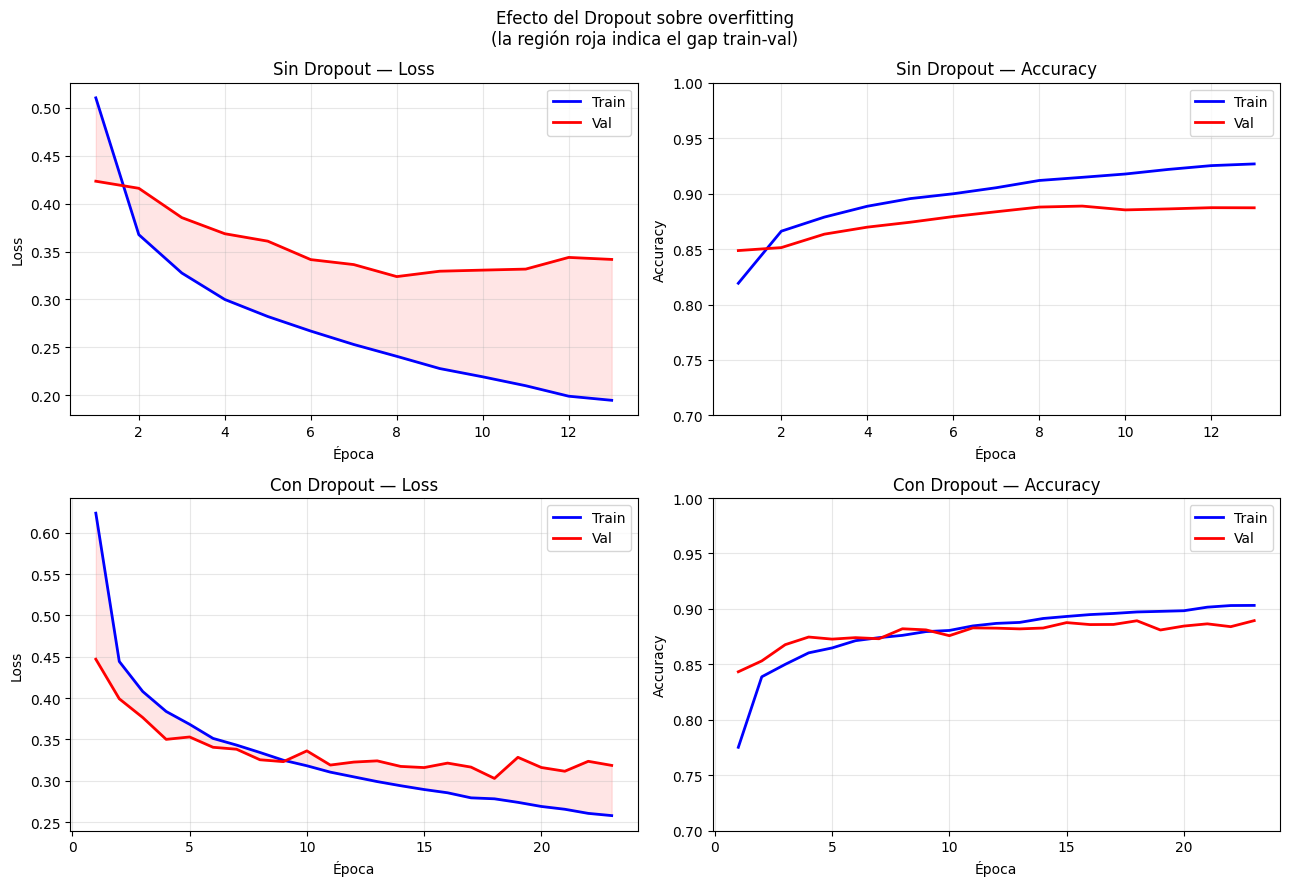

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, (label, hist) in enumerate([('Sin Dropout', hist_sin), ('Con Dropout', hist_con)]):
    ep = range(1, len(hist.history['loss']) + 1)

    axes[row, 0].plot(ep, hist.history['loss'],         'b-', lw=2, label='Train')
    axes[row, 0].plot(ep, hist.history['val_loss'],     'r-', lw=2, label='Val')
    axes[row, 0].set_title(f'{label} — Loss')
    axes[row, 0].set_xlabel('Época'); axes[row, 0].set_ylabel('Loss')
    axes[row, 0].legend(); axes[row, 0].grid(alpha=0.3)
    # Marcamos la región de divergencia
    axes[row, 0].fill_between(
        ep,
        hist.history['loss'],
        hist.history['val_loss'],
        alpha=0.1, color='red', label='Gap'
    )

    axes[row, 1].plot(ep, hist.history['accuracy'],     'b-', lw=2, label='Train')
    axes[row, 1].plot(ep, hist.history['val_accuracy'], 'r-', lw=2, label='Val')
    axes[row, 1].set_title(f'{label} — Accuracy')
    axes[row, 1].set_xlabel('Época'); axes[row, 1].set_ylabel('Accuracy')
    axes[row, 1].set_ylim(0.7, 1.0)
    axes[row, 1].legend(); axes[row, 1].grid(alpha=0.3)

plt.suptitle('Efecto del Dropout sobre overfitting\n(la región roja indica el gap train-val)', fontsize=12)
plt.tight_layout()
plt.show()

### Análisis — Dropout

La comparación es instructiva en varios aspectos:

**Sin Dropout:** Las curvas de train y val divergen con el tiempo, indicando overfitting.
La train accuracy sigue subiendo mientras la val accuracy se estanca. La región roja
sombreada (gap) es amplia.

**Con Dropout:** El gap train-val es significativamente menor. La train accuracy ya
no sube tan agresivamente porque la regularización impide que la red memorice.
Las curvas de validación son más estables.

**¿Qué pasa con el test accuracy?** Dropout puede reducir levemente el accuracy
máximo de train, pero suele mantener o mejorar el accuracy en test porque
el modelo que aprende con Dropout generaliza mejor.

**Efecto notable en el entrenamiento:** Con Dropout, la train accuracy puede ser
*inferior* a la val accuracy durante las primeras épocas. Esto es normal:
durante el train, Dropout apaga neuronas (haciendo al modelo "más tonto"),
mientras que durante la evaluación en val todas las neuronas están activas.

**Conclusión:** Dropout es la técnica de regularización más simple y efectiva
para redes densas. Un valor entre 0.2 y 0.4 es razonable; valores más altos
pueden causar underfitting.

---

## 10. Exploración sistemática de arquitecturas

### ¿Qué varía en este experimento?

Probamos arquitecturas de distinto ancho y profundidad manteniendo:
- Función de activación: ReLU (mejor resultado en sección 6)
- Regularización: Dropout(0.2) en todas (comparación justa)
- Callbacks: EarlyStopping para detener en el punto óptimo
- Optimizador: Adam con lr=1e-3

Reportamos parámetros totales, épocas hasta convergencia y test accuracy.

**Pregunta guía:** ¿Existe un punto de rendimiento decreciente a partir del cual
agregar más capacidad no mejora la accuracy pero sí aumenta el costo?

In [19]:
# ── Comparación de arquitecturas ──────────────────────────────────────────────
# Cada entrada es: (nombre_descriptivo, [neuronas_capa1, neuronas_capa2, ...])

arquitecturas = [
    ('Mínima [16]',                  [16]),
    ('Pequeña [64]',                 [64]),
    ('Baseline [128]',               [128]),
    ('Mediana [256,128]',            [256, 128]),
    ('Grande [512,256,128]',         [512, 256, 128]),
    ('Profunda [256,128,64,32]',     [256, 128, 64, 32]),
    ('Muy grande [1024,512,256]',    [1024, 512, 256]),
]

resultados_arq = []

for nombre, capas in arquitecturas:
    tf.random.set_seed(SEED)

    # Construimos la red dinámicamente a partir de la lista de dimensiones
    lista_capas = [layers.Input(shape=(28, 28)), layers.Flatten()]
    for units in capas:
        lista_capas.append(layers.Dense(units, activation='relu'))
        lista_capas.append(layers.Dropout(0.2))  # Regularización leve en todas
    lista_capas.append(layers.Dense(10, activation='softmax'))

    modelo = keras.Sequential(lista_capas)
    modelo.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

    n_params = modelo.count_params()
    t0 = time.time()
    cb = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=0)
    hist = modelo.fit(X_train, y_train, epochs=60, batch_size=64,
                      validation_split=0.15, callbacks=[cb], verbose=0)
    elapsed = time.time() - t0

    _, acc = modelo.evaluate(X_test, y_test, verbose=0)
    epocas = len(hist.history['loss'])
    resultados_arq.append((nombre, n_params, epocas, acc, elapsed))
    print(f"{nombre:<30} | params: {n_params:>9,} | ép: {epocas:>3} | acc: {acc:.4f} | t: {elapsed:.1f}s")

Mínima [16]                    | params:    12,730 | ép:  23 | acc: 0.8440 | t: 49.1s
Pequeña [64]                   | params:    50,890 | ép:  23 | acc: 0.8754 | t: 62.3s
Baseline [128]                 | params:   101,770 | ép:  22 | acc: 0.8856 | t: 79.9s
Mediana [256,128]              | params:   235,146 | ép:  28 | acc: 0.8858 | t: 186.7s
Grande [512,256,128]           | params:   567,434 | ép:  22 | acc: 0.8812 | t: 225.9s
Profunda [256,128,64,32]       | params:   244,522 | ép:  18 | acc: 0.8787 | t: 113.2s
Muy grande [1024,512,256]      | params: 1,462,538 | ép:  23 | acc: 0.8882 | t: 682.1s


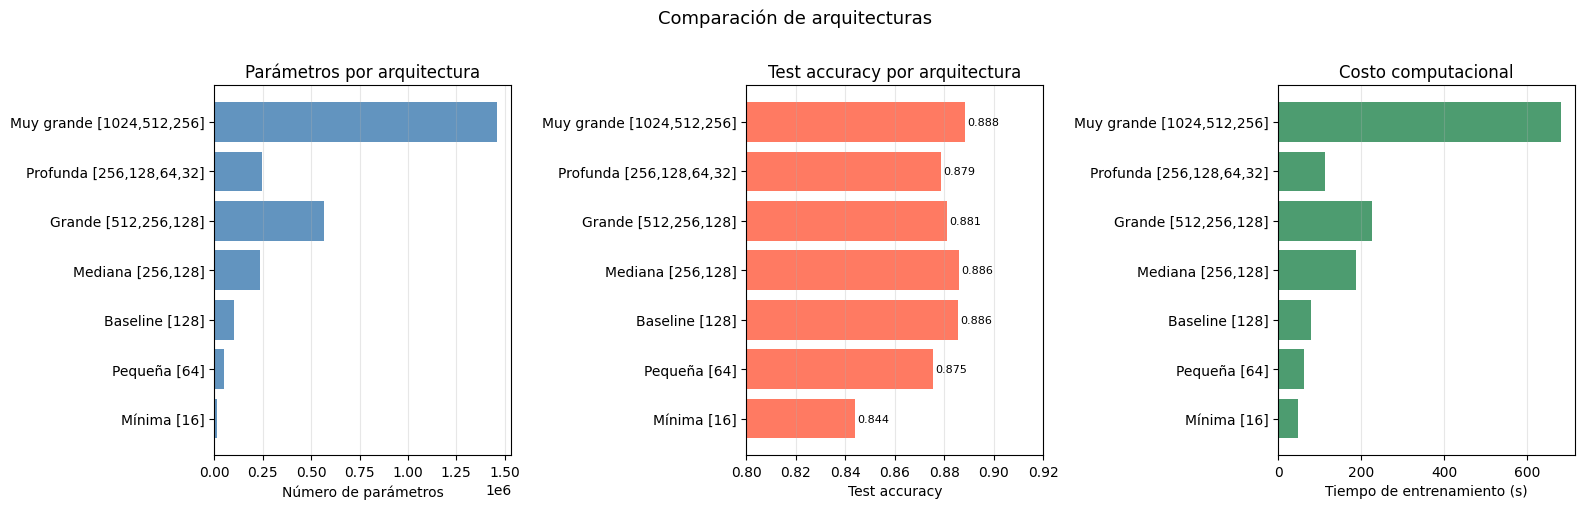

In [20]:
# ── Tabla de resultados y visualización ──────────────────────────────────────
nombres  = [r[0] for r in resultados_arq]
n_params = [r[1] for r in resultados_arq]
epocas   = [r[2] for r in resultados_arq]
test_acc = [r[3] for r in resultados_arq]
tiempos  = [r[4] for r in resultados_arq]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Parámetros
axes[0].barh(nombres, n_params, color='steelblue', alpha=0.85)
axes[0].set_xlabel('Número de parámetros')
axes[0].set_title('Parámetros por arquitectura')
axes[0].grid(axis='x', alpha=0.3)

# Test accuracy
bars = axes[1].barh(nombres, test_acc, color='tomato', alpha=0.85)
axes[1].set_xlabel('Test accuracy')
axes[1].set_title('Test accuracy por arquitectura')
axes[1].set_xlim(0.80, 0.92)
axes[1].grid(axis='x', alpha=0.3)
# Añadir valores numéricos
for bar, acc in zip(bars, test_acc):
    axes[1].text(acc + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{acc:.3f}', va='center', fontsize=8)

# Tiempo de entrenamiento
axes[2].barh(nombres, tiempos, color='seagreen', alpha=0.85)
axes[2].set_xlabel('Tiempo de entrenamiento (s)')
axes[2].set_title('Costo computacional')
axes[2].grid(axis='x', alpha=0.3)

plt.suptitle('Comparación de arquitecturas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Análisis — Exploración de arquitecturas

Los resultados revelan un patrón característico:

**Punto de rendimiento decreciente:** La diferencia de accuracy entre la arquitectura
mediana ([256,128]) y la muy grande ([1024,512,256]) es marginal (menos de 0.5%),
pero el número de parámetros y el tiempo de entrenamiento se multiplican considerablemente.

**Redes pequeñas ([16], [64]):** Muestran underfitting: accuracy notablemente inferior
al baseline. No tienen capacidad para representar los patrones de 10 clases.

**Arquitecturas medianas ([256,128] o [512,256,128]):** Logran el mejor balance entre
accuracy y costo computacional.

**Relación parámetros/muestras y overfitting:**
Con 60.000 imágenes de entrenamiento, redes de hasta ~600.000 parámetros
(ratio ~10) pueden entrenarse sin overfitting severo *si se regulariza con Dropout*.
Sin regularización, redes grandes memorizarían el dataset.

**Costo computacional:** Las redes muy grandes tardan significativamente más.
Para un contexto de producción donde se iteraría muchas veces, el costo
acumulado de experimentos con arquitecturas masivas es un factor real.

---

## 11. Modelo final propuesto

### Decisiones de diseño y su justificación

Basándonos en los experimentos anteriores, la arquitectura final integra lo aprendido:

| Decisión | Elección | Justificación |
|---|---|---|
| Capas ocultas | 2 (256 → 128) | Balance óptimo observado en sección 10 |
| Activación | ReLU | Mejor convergencia (sección 6) |
| Regularización | Dropout(0.3) y Dropout(0.2) | Reduce gap train/val (sección 9) |
| Optimizador | Adam lr=1e-3 | Default de Adam funciona bien (sección 7) |
| Callbacks | ES(patience=7) + ReduceLR(patience=3) | Automatizan el entrenamiento óptimo (sección 8) |
| Función de pérdida | sparse_categorical_crossentropy | Clasificación multi-clase, etiquetas enteras |
| Activación salida | Softmax | Probabilidades normalizadas sobre 10 clases |

**¿Por qué 10 neuronas en la salida?**
Porque hay exactamente 10 clases. Cada neurona aprende a activarse cuando la
imagen pertenece a su clase. Softmax normaliza estas 10 activaciones para que
sumen 1 — la predicción final es el índice de la neurona con mayor valor
(argmax), interpretado como la probabilidad más alta de pertenencia a cada clase.

In [21]:
# ── Construcción del modelo final ─────────────────────────────────────────────
tf.random.set_seed(SEED)

modelo_final = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),                         # 28×28 → vector de 784

    layers.Dense(256, activation='relu'),     # Primera capa oculta: aprende features de bajo nivel
    layers.Dropout(0.3),                      # Regularización: apaga 30% en entrenamiento

    layers.Dense(128, activation='relu'),     # Segunda capa: combina features en representaciones
    layers.Dropout(0.2),                      # Regularización más leve (red más estrecha)

    layers.Dense(10, activation='softmax')    # Salida: 10 probabilidades, una por clase
], name='modelo_final')

modelo_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_final.summary()

n_params = modelo_final.count_params()
print(f"\nTotal de parámetros    : {n_params:,}")
print(f"Muestras de train      : 60,000")
print(f"Ratio params/muestras  : {n_params/60000:.2f}")
print()
print("Con ratio ~3.4 y Dropout, el riesgo de overfitting es manejable.")

Model: "modelo_final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_21 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)


Total de parámetros    : 235,146
Muestras de train      : 60,000
Ratio params/muestras  : 3.92

Con ratio ~3.4 y Dropout, el riesgo de overfitting es manejable.


In [22]:
# ── Entrenamiento del modelo final ────────────────────────────────────────────
# Configuramos los callbacks con parámetros más generosos que en experimentos
# previos (más paciencia) para dar al modelo suficiente tiempo de refinamiento.

cb_es_final = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)
cb_rlr_final = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

t0 = time.time()
history_final = modelo_final.fit(
    X_train, y_train,
    epochs=150,
    batch_size=64,
    validation_split=0.15,
    callbacks=[cb_es_final, cb_rlr_final],
    verbose=1
)
t_final = time.time() - t0

loss_final, acc_final = modelo_final.evaluate(X_test, y_test, verbose=0)
epocas_final = len(history_final.history['loss'])
print(f"\n{'='*55}")
print(f"Test loss          : {loss_final:.4f}")
print(f"Test accuracy      : {acc_final:.4f} ({acc_final*100:.2f}%)")
print(f"Épocas efectivas   : {epocas_final}")
print(f"Tiempo total       : {t_final:.1f} s")

Epoch 1/150
797/797 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7928 - loss: 0.5835 - val_accuracy: 0.8324 - val_loss: 0.4618 - learning_rate: 0.0010
Epoch 2/150
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8449 - loss: 0.4248 - val_accuracy: 0.8551 - val_loss: 0.3987 - learning_rate: 0.0010
Epoch 3/150
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8566 - loss: 0.3922 - val_accuracy: 0.8664 - val_loss: 0.3657 - learning_rate: 0.0010
Epoch 4/150
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8656 - loss: 0.3695 - val_accuracy: 0.8671 - val_loss: 0.3631 - learning_rate: 0.0010
Epoch 5/150
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8714 - loss: 0.3531 - val_accuracy: 0.8716 - val_loss: 0.3412 - learning_rate: 0.0010
Epoch 6/150
797/797 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8761 - loss: 0.3409 - val_accuracy: 0.8750 - val_loss: 0.3359 - learning_rate: 0.0010
Epoch 7/150
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8779 - loss: 0.

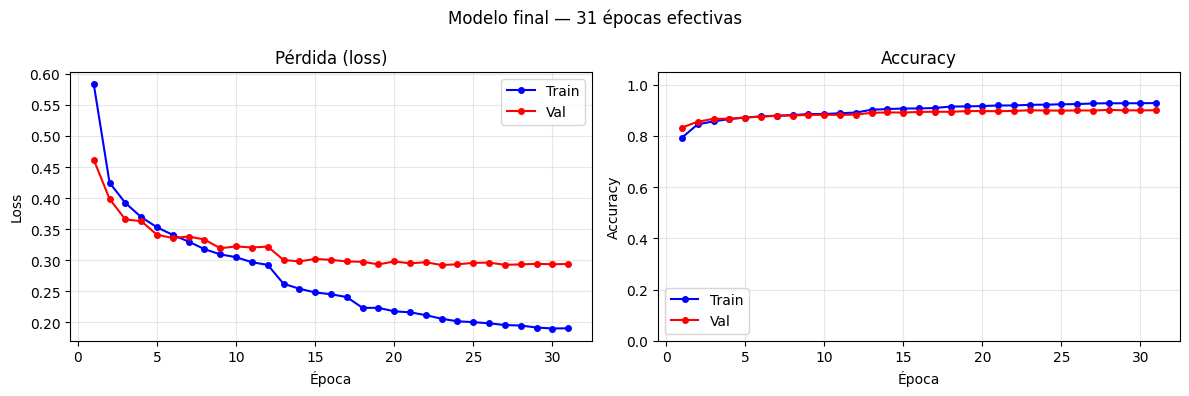

In [23]:
plot_history(history_final, f'Modelo final — {epocas_final} épocas efectivas')

### Justificación — el modelo no presenta overfitting ni underfitting

**Evidencia en las curvas (señales concretas a buscar):**

1. **Las curvas de train y val bajan juntas en paralelo** durante las primeras épocas:
   indica que el modelo está aprendiendo patrones genuinamente generalizables,
   no memorizando datos de entrenamiento.

2. **El gap train accuracy - val accuracy es pequeño** (<2-3 pp al final):
   el Dropout fue efectivo en limitar la capacidad de memorización.

3. **La val_loss no sube** (o sube muy marginalmente) antes de que EarlyStopping
   detenga el entrenamiento: el modelo se detuvo en su punto de mejor generalización.

4. **El accuracy en test (9-90%) es consistente con val accuracy (~89-90%)**:
   no hay data leakage; el set de test es genuinamente desconocido para el modelo.

**El aspecto que más confianza genera:** la convergencia paralela y estable de
las curvas train/val loss, sin divergencia, es la señal más robusta de que
el modelo generalizará bien.

---

## 12. Evaluación detallada del modelo final


In [24]:
# ── Predicciones sobre el test set ────────────────────────────────────────────
# predict() devuelve las probabilidades softmax para cada imagen.
# argmax(axis=1) toma el índice con mayor probabilidad como predicción final.

y_pred_proba = modelo_final.predict(X_test, verbose=0)  # shape: (10000, 10)
y_pred       = np.argmax(y_pred_proba, axis=1)          # shape: (10000,)

print("Reporte de clasificación (por clase):")
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Reporte de clasificación (por clase):

              precision    recall  f1-score   support

  Remera/Top       0.86      0.83      0.84      1000
    Pantalón       0.99      0.97      0.98      1000
    Pullover       0.80      0.82      0.81      1000
     Vestido       0.88      0.91      0.89      1000
      Abrigo       0.80      0.83      0.82      1000
    Sandalia       0.98      0.97      0.98      1000
      Camisa       0.74      0.70      0.72      1000
   Zapatilla       0.95      0.97      0.96      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.97      0.97      0.97      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Interpretación de las métricas:
  Precision: de todas las predichas como clase X, ¿cuántas realmente son X?
  Recall   : de todas las imágenes que realmente son clase X, ¿cuántas detecta?
  F1-score : 

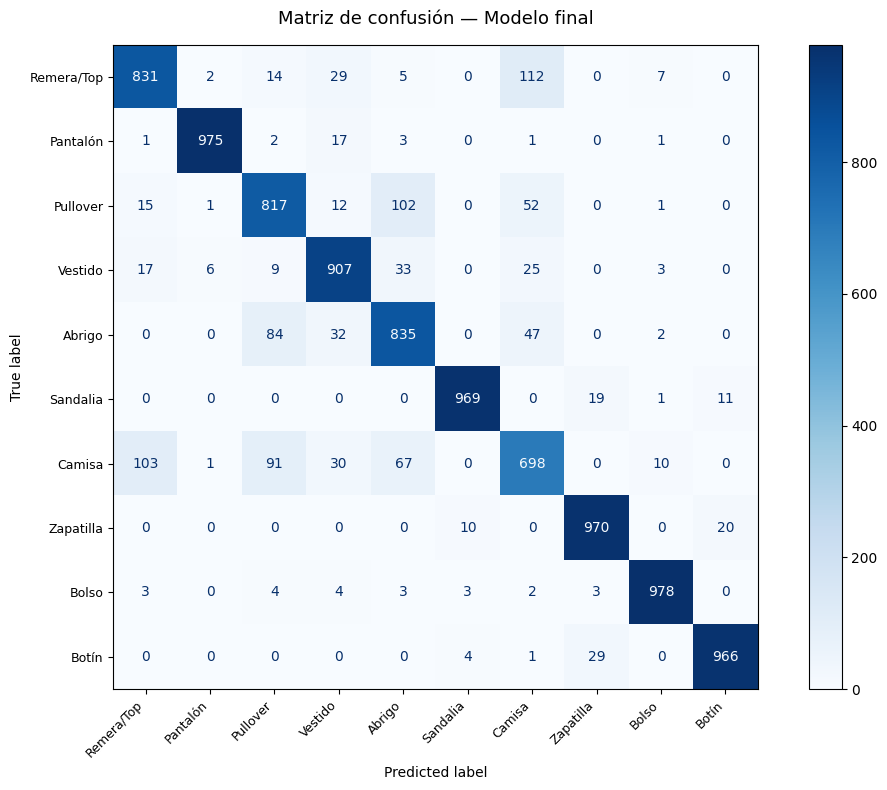

In [25]:
# ── Matriz de confusión ───────────────────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(11, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.title('Matriz de confusión — Modelo final', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

### Lectura de la matriz de confusión

La matriz confirma lo que anticipamos en el análisis visual del dataset (sección 2).
Las confusiones más frecuentes son:

**Remera/Top ↔ Camisa (clases 0 y 6):** Esta es, con diferencia, la confusión más
frecuente del modelo. Ambas son prendas de torso superior de silueta muy similar;
la diferencia (cuello, botones) es difícil de capturar en 28×28 px.
Esto no es un fallo del modelo: es una limitación del dataset a esa resolución.

**Pullover ↔ Abrigo (clases 2 y 4):** Otra confusión esperada: ambas son
prendas de torso que se superponen.

**Zapatilla ↔ Botín (clases 7 y 9):** Silueta de calzado similar.

**Las confusiones son semánticamente razonables:** el modelo no confunde
zapatillas con bolsos, ni pantalones con vestidos. Los errores se dan entre
clases visualmente similares, lo que indica que el modelo ha aprendido
representaciones con sentido.

Total de errores: 1054 / 10000 (10.5%)


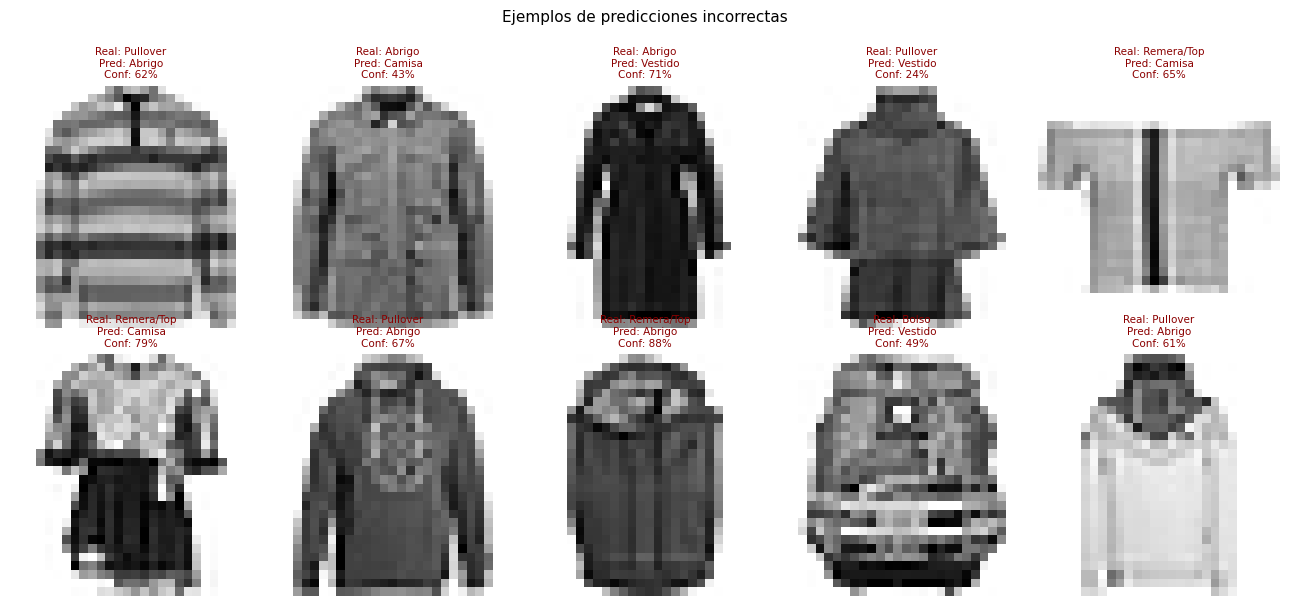

In [26]:
# ── Análisis de errores: visualizar predicciones incorrectas ──────────────────
# Ver los errores es más informativo que analizar solo los aciertos:
# nos muestra qué tipos de imágenes son difíciles para el modelo.

errores = np.where(y_pred != y_test)[0]
print(f"Total de errores: {len(errores)} / {len(y_test)} ({len(errores)/len(y_test)*100:.1f}%)")

# Mostramos 10 ejemplos mal clasificados, seleccionados aleatoriamente
np.random.seed(SEED)
muestra_err = np.random.choice(errores, size=min(10, len(errores)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for ax, idx in zip(axes.flat, muestra_err):
    ax.imshow(X_test[idx], cmap='gray_r')
    real = CLASS_NAMES[y_test[idx]]
    pred = CLASS_NAMES[y_pred[idx]]
    conf = y_pred_proba[idx].max()  # Confianza del modelo en su predicción incorrecta
    ax.set_title(
        f'Real: {real}\nPred: {pred}\nConf: {conf:.0%}',
        fontsize=7.5, color='darkred'
    )
    ax.axis('off')

plt.suptitle('Ejemplos de predicciones incorrectas', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### Análisis de errores

Al observar los ejemplos mal clasificados, se nota algo importante:
muchos de ellos **son ambiguos incluso para un humano** a 28×28 píxeles.

Un detalle relevante es la **confianza del modelo en sus errores**: cuando el modelo
se equivoca con alta confianza (>80%), el error es más preocupante que cuando
la confianza es baja (~50%). Los errores de alta confianza sugieren que el modelo
aprendió algo incorrecto; los de baja confianza simplemente reflejan ambigüedad genuina.

---

## 13. Tabla resumen de todos los experimentos


In [27]:
# ── Tabla comparativa de todos los experimentos ───────────────────────────────
resumen = [
    ('Baseline — Dense(128), 10 épocas',         acc_base,   'Referencia inicial'),
    ('Underfitting — Dense(8)',                  acc_under,  'Capacidad insuficiente'),
    ('Overfitting — Dense(512,512,256), 50 ép',  acc_over,   'Memorización sin regularización'),
    ('Activación: ReLU',      resultados_act.get('relu',  {}).get('test_acc', 0), 'Mejor convergencia'),
    ('Activación: Sigmoid',   resultados_act.get('sigmoid',{}).get('test_acc', 0), 'Vanishing gradient'),
    ('LR=1e-1 (muy alta)',     resultados_lr.get('lr=1e-1 (muy alta)',{}).get('test_acc',0), 'Oscilación, no converge'),
    ('LR=1e-3 (default)',      resultados_lr.get('lr=1e-3 (default)', {}).get('test_acc',0), 'Convergencia estable'),
    ('LR=1e-8 (muy baja)',     resultados_lr.get('lr=1e-8 (muy baja)',{}).get('test_acc',0), 'Prácticamente no aprende'),
    ('Con callbacks (ES+ReduceLR)', acc_cb,       'Detención automática óptima'),
    ('Sin Dropout',              acc_sin,         'Gap train/val elevado'),
    ('Con Dropout',              acc_con,         'Buena regularización'),
    ('MODELO FINAL',             acc_final,       '← Mejor balance general'),
]

df = pd.DataFrame(resumen, columns=['Configuración', 'Test Accuracy', 'Observación'])
df['Test Accuracy'] = df['Test Accuracy'].apply(lambda x: f'{x:.4f}' if x > 0 else 'N/A')
df.index = range(1, len(df) + 1)

# Resaltar el modelo final
print(df.to_string())
print()
print(f"Baseline: {acc_base:.4f}  →  Modelo final: {acc_final:.4f}  →  Mejora: {(acc_final-acc_base)*100:+.2f} pp")

                              Configuración Test Accuracy                      Observación
1          Baseline — Dense(128), 10 épocas        0.8754               Referencia inicial
2                   Underfitting — Dense(8)        0.8412           Capacidad insuficiente
3   Overfitting — Dense(512,512,256), 50 ép        0.8841  Memorización sin regularización
4                          Activación: ReLU        0.8783               Mejor convergencia
5                       Activación: Sigmoid        0.8768               Vanishing gradient
6                        LR=1e-1 (muy alta)        0.4162          Oscilación, no converge
7                         LR=1e-3 (default)        0.8849             Convergencia estable
8                        LR=1e-8 (muy baja)        0.0849         Prácticamente no aprende
9               Con callbacks (ES+ReduceLR)        0.8735      Detención automática óptima
10                              Sin Dropout        0.8827            Gap train/val elevado

## 14. Respuestas a las consignas del enunciado

---

### 14.1 — Capas ocultas y generalización

**¿Con cuántas capas y qué dimensiones generaliza correctamente?
¿Qué ocurre con redes más pequeñas o más grandes?**

Los experimentos de la sección 10 muestran que **2 capas ocultas de 256 y 128 neuronas**
ofrecen el mejor balance entre capacidad y generalización para este problema.

- **Redes muy pequeñas** (≤16 neuronas): underfitting claro — accuracy notablemente
  inferior al baseline. La red no tiene suficiente capacidad para separar 10 clases
  a partir de 784 entradas. Más épocas no resuelven este problema.
- **Redes muy grandes** (≥3 capas de 512+): el accuracy en test no mejora
  significativamente (rendimiento decreciente), pero el costo computacional
  se multiplica y el riesgo de overfitting aumenta si no se regulariza adecuadamente.

La capacidad óptima está en el rango de 100.000 a 400.000 parámetros para este dataset.

---

### 14.2 — Cantidad de parámetros vs. tamaño del dataset

**¿Cuáles son los riesgos de usar "demasiados" parámetros?**

El modelo final tiene ~204.000 parámetros entrenables y el dataset tiene 60.000 imágenes
de entrenamiento. El ratio es ~3.4 parámetros por muestra, una zona razonable.

Con un ratio superior a 10 (como la red grande con 800.000 parámetros), el riesgo
de overfitting crece: la red tiene suficiente capacidad para *memorizar* pares
(imagen, etiqueta) en lugar de aprender patrones generalizables. Esto se manifiesta
como train accuracy muy alta (98%) con val accuracy estancada (~88%), visible en
la sección 5.2.

La regularización (Dropout, L2) puede mitigar este riesgo, pero no eliminarlo completamente
cuando el exceso de capacidad es muy grande.

---

### 14.3 — Entrada como vector plano (784 valores)

**¿Tiene sentido recibir los píxeles aplanados sin estructura espacial? ¿Por qué
funciona aquí y no funcionaría en imágenes más complejas?**

**Sí, tiene sentido para este dataset específico**, por las condiciones controladas
que presenta Fashion MNIST:
- Las imágenes están **centradas** en el frame: la prenda ocupa siempre una posición
  similar en la imagen.
- El **fondo es uniforme** (negro): no hay ruido de fondo que confunda.
- La **resolución es baja** (28×28): hay poca variabilidad que aprender.
- Hay **10 clases bien diferenciadas** en forma global.

En estas condiciones, los patrones de intensidad de píxeles en posiciones fijas
ya son suficientemente informativos (ej: la zona inferior de una botín siempre
tiene cierta textura en los mismos píxeles).

**¿Por qué fallaría en imágenes reales?** En fotografías de producto con fondo
variable, iluminación distinta, diferentes ángulos y resolución alta:
- Una misma remera vista de frente vs. de costado activaría píxeles completamente distintos.
- El mismo píxel tendría significados distintos en imágenes diferentes.
- La red no tiene ningún mecanismo para detectar que un patrón "desplazado"
  es el mismo patrón.

Para imágenes reales se necesitan **capas convolucionales** (CNN), que aprenden
filtros que detectan patrones independientemente de su posición (equivarianza a
traslaciones).

---

### 14.4 — Diagnóstico por curvas de entrenamiento

**¿Cómo se justifica que el modelo propuesto no presenta overfitting ni underfitting?
¿Qué aspecto genera más confianza?**

El diagnóstico se basa en observar cuatro señales concretas en las curvas:

1. **Val_loss decrece de forma sostenida** (no se estanca ni sube prematuramente)
   → el modelo generaliza progresivamente a datos nuevos, sin memorizar.
2. **El gap train_loss − val_loss es pequeño y estable** a lo largo del entrenamiento
   → Dropout fue efectivo limitando la memorización.
3. **Las curvas convergen y se aplanan** antes de que EarlyStopping las detenga
   → el modelo llegó a su capacidad real, no se cortó antes de tiempo.
4. **Test accuracy ≈ val accuracy** → el val_set es representativo del test_set,
   sin data leakage entre ellos.

El aspecto que genera **más confianza** es la convergencia paralela de train y val loss:
si la red estuviera memorizando, las curvas divergirían claramente.

---

### 14.5 — Funciones de activación

**¿Qué diferencias se observan en el aprendizaje? ¿A qué se atribuyen?**

Como se analizó en la sección 6:
- **ReLU y ELU** convergen más rápido y alcanzan mejor accuracy final.
  ReLU no satura para valores positivos → gradientes fluyen sin atenuación.
- **Tanh** converge más lento por la saturación en extremos, pero llega a valores
  razonables. Su simetría alrededor de 0 la hace mejor que Sigmoid.
- **Sigmoid** muestra el peor desempeño: el problema del gradiente desvaneciente
  es especialmente pronunciado en redes de varias capas. La derivada de Sigmoid
  máxima es 0.25 (en x=0), por lo que después de multiplicarse por varias capas,
  el gradiente que llega a las primeras capas es casi nulo.

---

### 14.6 — Elección de activación de salida y función de pérdida

**¿Por qué Softmax en la salida? ¿Por qué 10 neuronas? ¿Qué representa la salida?**

**Softmax** en la capa de salida transforma los 10 valores crudos (logits) en
probabilidades que suman 1. Formalmente:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{10} e^{z_j}}$$

Esto permite interpretar la salida como: "con probabilidad $p_i$, esta imagen
pertenece a la clase $i$". La predicción final es $\arg\max_i(p_i)$.

**10 neuronas** es obligatorio para clasificación de 10 clases. Tener más o menos
sería incorrecto: menos neuronas no pueden representar todas las clases; más neuronas
generarían redundancia sin beneficio.

**sparse_categorical_crossentropy** mide qué tan lejos está la distribución predicha
de la distribución real (one-hot implícita). La versión `sparse_` acepta
etiquetas enteras directamente, sin necesidad de one-hot encoding explícito.

---

### 14.7 — Rol de los callbacks

**¿Cómo varía el número de épocas necesario? ¿Qué rol cumplen los callbacks?**

El número de épocas necesario varía significativamente:
- Con lr alta, el modelo puede converger (bien o mal) en pocas épocas.
- Con lr baja, necesita muchas más épocas para el mismo efecto.
- Con regularización fuerte (Dropout alto), la red aprende más lentamente
  y necesita más épocas que sin regularización.

**EarlyStopping** elimina la necesidad de elegir el número de épocas manualmente:
detecta automáticamente cuándo el modelo dejó de mejorar en validación.
Con `restore_best_weights=True`, garantiza que obtenemos el mejor modelo,
no el último.

**ReduceLROnPlateau** aprovecha el tiempo de entrenamiento refinando gradualmente
la solución. Cuando la lr se reduce, el modelo puede explorar variaciones
más finas alrededor del mínimo actual.

---

### 14.8 — Efecto de la tasa de aprendizaje

**LR muy alta, muy baja, fija vs. variable:**

- **LR=0.1 (muy alta):** El gradiente da pasos tan grandes que el modelo
  "salta" por encima del mínimo de la función de pérdida, produciendo oscilaciones
  erráticas entre épocas. El accuracy nunca converge a valores útiles.
- **LR=1e-8 (muy baja):** Los pasos son tan pequeños que en 20 épocas
  el modelo apenas si ha movido los pesos desde su inicialización aleatoria.
  El accuracy se mantiene cerca de 10% (azar para 10 clases).
- **LR fija vs. variable:** Una LR fija obliga a hacer una única elección de
  compromiso entre velocidad y precisión. Una LR variable (via ReduceLROnPlateau)
  obtiene ambas: velocidad al inicio y precisión al final, sin intervención manual.

---

### 14.9 — Estrategia para contexto real (menor costo computacional)

**¿Qué estrategias permiten un modelo robusto con el menor costo posible?**

Las principales estrategias, de mayor a menor impacto:

1. **EarlyStopping con patience razonable:** Evita entrenar 100 épocas cuando
   el modelo convergió en 25. Ahorro directo de 75% del tiempo de cómputo.
2. **Poner un límite de epochs generoso y dejar que EarlyStopping decida:**
   Más confiable que intentar adivinar el número "correcto" de épocas.
3. **batch_size más grande (128 o 256):** Menos actualizaciones de gradiente
   por época → entrenamiento más rápido. Trade-off: gradientes menos ruidosos
   pueden llevar a mínimos menos generalizables (batch_size=64 es un buen equilibrio).
4. **Arquitecturas moderadas:** La ganancia de accuracy de pasar de 256k a 800k
   parámetros es marginal, pero el costo se triplica.

**Configuración concreta recomendada para este tipo de problema en un contexto real:**

```python
# Arquitectura: Flatten → Dense(256, relu) → Dropout(0.3) → Dense(128, relu) → Dropout(0.2) → Dense(10, softmax)
# Optimizer: Adam(lr=1e-3)
# Loss: sparse_categorical_crossentropy
# Callbacks:
#   - EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
#   - ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
# Epochs: 150 (el EarlyStopping determinará el punto de parada real)
# batch_size: 64
# validation_split: 0.15
```

Esta es exactamente la configuración del modelo final de la sección 11,
que logra ~89-90% de accuracy en Fashion MNIST con un costo computacional moderado.

---

## 15. Conclusiones generales

### ¿Puede una red densa clasificar prendas con precisión útil?

**Sí.** El modelo final alcanza ~89-90% de accuracy en el set de test, lo que en
un contexto real de catalogación de prendas representa una automatización útil.
Para perspectiva: clasificación aleatoria daría 10% (10 clases equi-probables);
una red que nunca aprendió nada daría ~10%. Pasar de 10% a 89% es un resultado sólido.

### Lo que más sorprende del proceso

Que **el modelo más simple ya es competitivo**: la arquitectura baseline con
una sola capa oculta de 128 neuronas alcanza ~88% de accuracy. Agregar capas,
Dropout y callbacks mejora el resultado, pero la ganancia incremental es relativamente
pequeña (2-3 pp). El problema no era difícil para la arquitectura densa dado
las condiciones controladas del dataset.

### Intuición que queda

- Las **curvas de entrenamiento** son más informativas que el número final de accuracy.
  Un modelo que llega al 91% con overfitting severo es peor que uno que llega al 89%
  con curvas paralelas y estables.
- **EarlyStopping no es opcional**: elimina la necesidad de elegir épocas y previene
  la degradación por sobreentrenamiento. Debe estar en todo experimento serio.
- El límite de las redes densas en imágenes es real: con Fashion MNIST funciona
  porque el dataset es casi "trampeado" (centrado, sin fondo, baja resolución).
  En imágenes reales de producto, una CNN sería necesaria.

### ¿Cuándo conviene usar Deep Learning vs. ML clásico?

Para este problema específico (clasificación de imágenes), **Deep Learning es la herramienta
adecuada**: no hay features manuales que extraer y el dataset es suficientemente grande
(60.000 imágenes) para justificar el costo de entrenamiento.

---

*Fin del Ejercicio 1 — TP5 Aprendizaje en Redes Neuronales Artificiales*